In [11]:
!pip install nltk -q

import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')
import nltk





[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [4]:
df = pd.read_csv(
    "training.csv",
    encoding="latin-1",
    header=None,
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)
print(df.head())

(1600000, 6)
   0           1                             2         3                4  \
0  0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_   
1  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton   
2  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY         mattycus   
3  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          ElleCTF   
4  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY           Karoli   

                                                   5  
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1  is upset that he can't update his Facebook by ...  
2  @Kenichan I dived many times for the ball. Man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  


In [5]:


print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   0       1600000 non-null  int64 
 1   1       1600000 non-null  int64 
 2   2       1600000 non-null  object
 3   3       1600000 non-null  object
 4   4       1600000 non-null  object
 5   5       1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB
None
0    0
1    0
2    0
3    0
4    0
5    0
dtype: int64


In [6]:
df = df.sample(1000, random_state=1)

print(df.shape)

(1000, 6)


In [8]:
df.columns = [
    "Sentiment",
    "ID",
    "Date",
    "Query",
    "User",
    "Complaint"
]

print(df.head())

        Sentiment          ID                          Date     Query  \
514293          0  2190584004  Tue Jun 16 03:08:48 PDT 2009  NO_QUERY   
142282          0  1881451988  Fri May 22 04:42:15 PDT 2009  NO_QUERY   
403727          0  2058252964  Sat Jun 06 14:34:17 PDT 2009  NO_QUERY   
649503          0  2237307600  Fri Jun 19 05:34:22 PDT 2009  NO_QUERY   
610789          0  2224301193  Thu Jun 18 09:20:06 PDT 2009  NO_QUERY   

               User                                          Complaint  
514293    Vicki_Gee  i miss nikki nu nu already  shes always there ...  
142282    PatCashin  So I had a dream last night. I  remember a sig...  
403727  deelectable  @girlyghost ohh poor sickly you   (((hugs)) ho...  
649503  justinekepa                               it is raining again   
610789     cmatt007          @MissKeriBaby wish I was in LA right now   


In [9]:
df = df.sample(1000, random_state=1)

print(df.shape)

(1000, 6)


In [12]:
stop_words = set(stopwords.words("english"))

clean_text = []

for text in df["Complaint"]:

    text = str(text).lower()

    words = word_tokenize(text)

    words = [word for word in words if word.isalpha()]

    words = [word for word in words if word not in stop_words]

    clean_text.append(" ".join(words))

df["Clean_Text"] = clean_text

print(df[["Complaint", "Clean_Text"]].head())

                                                 Complaint  \
1580223                 I've put twitter in my blog! Cool    
47549               just found out my nan is in hospital     
1320078  @shiggybythebay Foster's was one of the best c...   
848880   @kimmikennedy How U enjoy it, every1 else i kn...   
1181995  Paranoia make us do weird things to the outsid...   

                                                Clean_Text  
1580223                              put twitter blog cool  
47549                                   found nan hospital  
1320078  shiggybythebay foster one best cartoons ever l...  
848880             kimmikennedy u enjoy else know saw says  
1181995     paranoia make us weird things outside observer  


In [13]:
sia = SentimentIntensityAnalyzer()

score = []

for text in df["Clean_Text"]:

    s = sia.polarity_scores(text)

    score.append(s["compound"])

df["Score"] = score

In [14]:
category = []

for s in df["Score"]:

    if s > 0:
        category.append("Positive")

    elif s < 0:
        category.append("Negative")

    else:
        category.append("Neutral")

df["Category"] = category

print(df[["Complaint","Category"]].head())

                                                 Complaint  Category
1580223                 I've put twitter in my blog! Cool   Positive
47549               just found out my nan is in hospital     Neutral
1320078  @shiggybythebay Foster's was one of the best c...  Positive
848880   @kimmikennedy How U enjoy it, every1 else i kn...  Positive
1181995  Paranoia make us do weird things to the outsid...  Negative


In [15]:
print(df["Category"].value_counts())

Category
Positive    487
Neutral     273
Negative    240
Name: count, dtype: int64


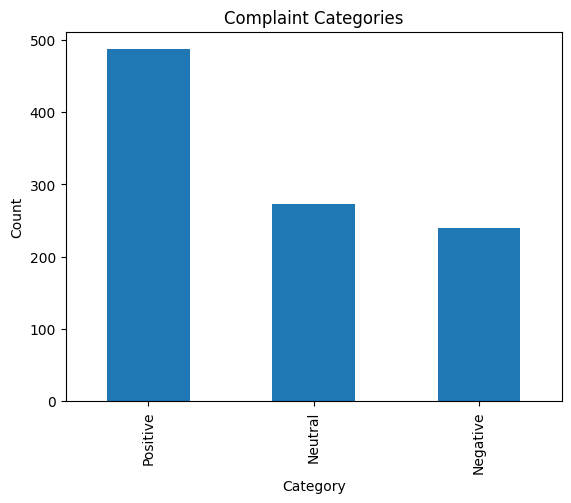

In [16]:
df["Category"].value_counts().plot(kind="bar")

plt.title("Complaint Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [17]:
all_words = " ".join(df["Clean_Text"])

words = all_words.split()

word_count = pd.Series(words).value_counts()

print(word_count.head(10))

get      57
good     56
got      51
back     48
day      47
like     46
today    46
one      45
http     45
time     42
Name: count, dtype: int64


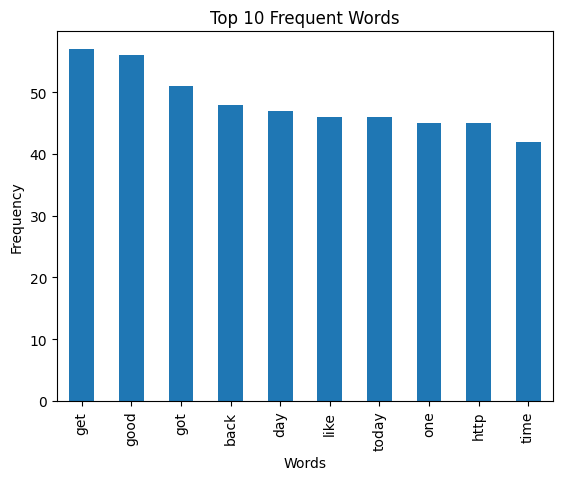

In [18]:
word_count.head(10).plot(kind="bar")

plt.title("Top 10 Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [19]:
df.to_csv("Banking_Complaint_Report.csv", index=False)

print("Report Saved Successfully")

Report Saved Successfully
